In [1]:
from datetime import datetime, timezone, timedelta
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from predictor.fetch import HRRRSource
from predictor.rules import (
    RuleBasedPredictor,
    MidHighCloudPresence, LowCloudObstruction,
    SolarAngleAtSunset, HumidityFactor,
)

In [2]:
# --- Config: edit me ---
QUERY_TIME = datetime(2026, 5, 21, 3, 30, tzinfo=timezone.utc)  # 2026-05-20 20:30 PDT (Forks, WA)
BBOX = (-125.2, 47.3, -123.8, 48.3)  # Olympic Peninsula coast (lon_min, lat_min, lon_max, lat_max)
GRID_RES = 0.1  # ~10 km grid

In [3]:
source = HRRRSource(cache_dir=Path("../../research/data/cache/hrrr"))
predictor = RuleBasedPredictor(
    rules=[
        MidHighCloudPresence(),
        LowCloudObstruction(),
        SolarAngleAtSunset(),
        HumidityFactor(),
    ],
    weights={
        "mid_high_cloud_presence": 2.0,
        "low_cloud_obstruction": 2.0,
        "solar_angle": 1.5,
        "humidity": 1.0,
    },
    source=source,
)

In [4]:
lon_min, lat_min, lon_max, lat_max = BBOX
lons = np.arange(lon_min, lon_max + GRID_RES, GRID_RES)
lats = np.arange(lat_min, lat_max + GRID_RES, GRID_RES)

LON, LAT = np.meshgrid(lons, lats)
PROB = np.full_like(LON, np.nan, dtype=float)

# Note: HRRRSource caches Herbie downloads, so the first cell is slow,
# subsequent cells fast. For a single run cycle, every grid point hits the
# same GRIB2 file.
for j, lat in enumerate(lats):
    for i, lon in enumerate(lons):
        try:
            forecast = predictor.score(lat=float(lat), lon=float(lon), time=QUERY_TIME)
            PROB[j, i] = forecast.probability
        except Exception as e:
            # Outside HRRR domain or grid mismatch → leave NaN
            PROB[j, i] = np.nan

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-May-21 04:00 UTC F02 ┊ GRIB2 @ aws ┊ IDX @ aws


Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.


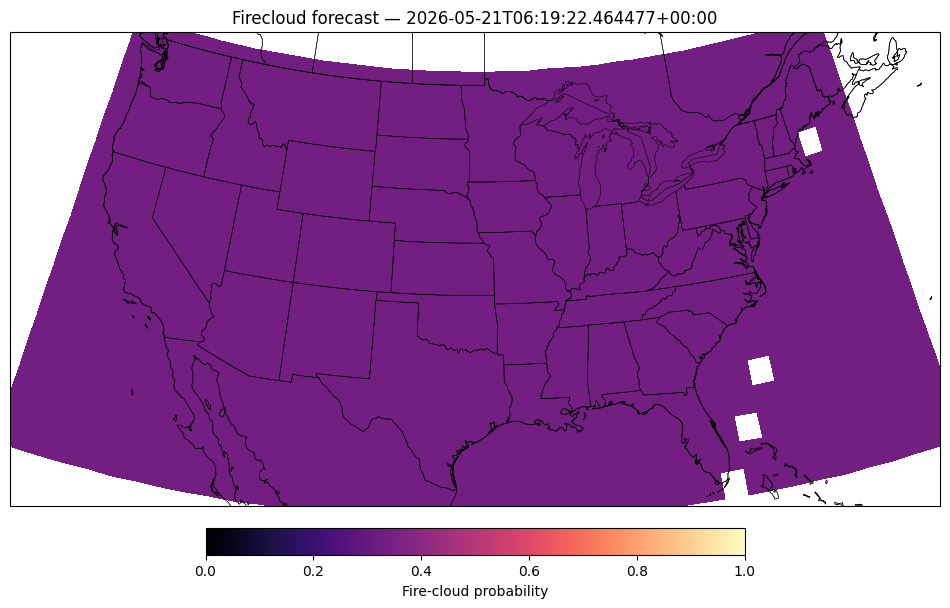

In [5]:
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-124, central_latitude=47.8))
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

mesh = ax.pcolormesh(
    LON, LAT, PROB,
    transform=ccrs.PlateCarree(),
    cmap="magma", vmin=0, vmax=1, shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, fraction=0.05)
cbar.set_label("Fire-cloud probability")

# Mark named locations
for name, lat, lon in [("La Push", 47.91, -124.64),
                       ("Ruby Beach", 47.71, -124.42),
                       ("Forks", 47.95, -124.39)]:
    ax.plot(lon, lat, marker='*', color='cyan', markersize=14,
            markeredgecolor='black', transform=ccrs.PlateCarree())
    ax.text(lon + 0.03, lat + 0.03, name, transform=ccrs.PlateCarree(),
            fontsize=10, color='white',
            bbox=dict(facecolor='black', alpha=0.55, pad=1, edgecolor='none'))

ax.set_title(f"Firecloud forecast — {QUERY_TIME.isoformat()}")
plt.show()

In [6]:
flat = PROB.flatten()
valid = ~np.isnan(flat)
order = np.argsort(flat[valid])
ranked_lats = LAT.flatten()[valid][order]
ranked_lons = LON.flatten()[valid][order]
ranked_probs = flat[valid][order]

print("Bottom 3 cells:")
for k in range(3):
    print(f"  ({ranked_lats[k]:.2f}, {ranked_lons[k]:.2f}) \u2192 {ranked_probs[k]:.2f}")

print("\nTop 3 cells:")
for k in range(1, 4):
    print(f"  ({ranked_lats[-k]:.2f}, {ranked_lons[-k]:.2f}) \u2192 {ranked_probs[-k]:.2f}")

# Detailed explanation for the top point
top_lat, top_lon = float(ranked_lats[-1]), float(ranked_lons[-1])
top_forecast = predictor.score(top_lat, top_lon, QUERY_TIME)
print("\nTop point detail:")
print(f"  {top_forecast.explanation}")
print(f"  inputs: {top_forecast.inputs}")

Bottom 3 cells:
  (25.00, -125.00) → 0.33
  (41.50, -111.50) → 0.33
  (41.50, -110.00) → 0.33

Top 3 cells:
  (49.00, -66.50) → 0.33
  (32.50, -89.00) → 0.33
  (32.50, -77.00) → 0.33

Top point detail:
  Composite=0.33 from mid_high_cloud_presence=0.00, low_cloud_obstruction=1.00, solar_angle=0.00, humidity=0.16
  inputs: {'cloud_low_pct': 16.0, 'cloud_mid_pct': 0.0, 'cloud_high_pct': 0.0, 'humidity_pct': 92.5999984741211, 'source_label': 'hrrr@2026-05-21T04Z+f02', 'retrieved_at': '2026-05-21T05:19:32.140292+00:00'}
